<a href="https://colab.research.google.com/github/Haarya/Online--Video-Transcoding-Time/blob/main/Regression_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Import Statements**

In [ ]:
import pandas as pd
import os # Add os import for path existence check

# Load the dataset using tab separator
file_path = '/content/transcoding_mesurment.tsv'

# Ensure the file exists before attempting to read it
if not os.path.exists(file_path):
    print(f"Error: The dataset file was not found at '{file_path}'. "
          "Please verify the file path or ensure the file has been uploaded.")
    df = None # Explicitly set df to None to prevent NameError downstream
else:
    try:
        df = pd.read_csv(file_path, sep='\t')
        print(f"Successfully loaded data from '{file_path}'. Dataframe shape: {df.shape}")

        # 1. Structural Audit: Initial Preview
        display(df.head())

    except Exception as e:
        print(f"An error occurred while reading the CSV file from '{file_path}': {e}")
        df = None # Explicitly set df to None if an error occurs during reading

# If df is still None, further operations will likely fail with a NameError.
# The downstream cells assume df is successfully loaded.
# This check ensures we don't proceed with an undefined df.
if df is None:
    print("DataFrame 'df' could not be loaded. Please address the error above before proceeding.")

Successfully loaded data from '/content/transcoding_mesurment.tsv'. Dataframe shape: (68784, 22)


,id,duration,codec,width,height,bitrate,framerate,i,p,b,...,p_size,b_size,size,o_codec,o_bitrate,o_framerate,o_width,o_height,umem,utime
0,04t6-jw9czg,130.35667,mpeg4,176,144,54590,12.0,27,1537,0,...,825054,0,889537,mpeg4,56000,12.0,176,144,22508,0.612
1,04t6-jw9czg,130.35667,mpeg4,176,144,54590,12.0,27,1537,0,...,825054,0,889537,mpeg4,56000,12.0,320,240,25164,0.980
2,04t6-jw9czg,130.35667,mpeg4,176,144,54590,12.0,27,1537,0,...,825054,0,889537,mpeg4,56000,12.0,480,360,29228,1.216
3,04t6-jw9czg,130.35667,mpeg4,176,144,54590,12.0,27,1537,0,...,825054,0,889537,mpeg4,56000,12.0,640,480,34316,1.692
4,04t6-jw9czg,130.35667,mpeg4,176,144,54590,12.0,27,1537,0,...,825054,0,889537,mpeg4,56000,12.0,1280,720,58528,3.456


In [ ]:
# 2. Structural Audit: Schema and Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68784 entries, 0 to 68783
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           68784 non-null  object 
 1   duration     68784 non-null  float64
 2   codec        68784 non-null  object 
 3   width        68784 non-null  int64  
 4   height       68784 non-null  int64  
 5   bitrate      68784 non-null  int64  
 6   framerate    68784 non-null  float64
 7   i            68784 non-null  int64  
 8   p            68784 non-null  int64  
 9   b            68784 non-null  int64  
 10  frames       68784 non-null  int64  
 11  i_size       68784 non-null  int64  
 12  p_size       68784 non-null  int64  
 13  b_size       68784 non-null  int64  
 14  size         68784 non-null  int64  
 15  o_codec      68784 non-null  object 
 16  o_bitrate    68784 non-null  int64  
 17  o_framerate  68784 non-null  float64
 18  o_width      68784 non-null  int64  
 19  o_he

In [ ]:
# 3. Structural Audit: Statistical Summary
display(df.describe())

,duration,width,height,bitrate,framerate,i,p,b,frames,i_size,p_size,b_size,size,o_bitrate,o_framerate,o_width,o_height,umem,utime
count,68784.000000,68784.000000,68784.000000,6.878400e+04,68784.000000,68784.000000,68784.000000,68784.000000,68784.000000,6.878400e+04,6.878400e+04,68784.0,6.878400e+04,6.878400e+04,68784.000000,68784.000000,68784.000000,68784.000000,68784.000000
mean,286.413921,624.934171,412.572226,6.937015e+05,23.241321,100.868312,6531.692210,9.147854,6641.708377,2.838987e+06,2.218057e+07,0.0,2.502294e+07,1.395036e+06,21.190862,802.336357,503.825541,228224.717900,9.996355
std,287.257650,463.169069,240.615472,1.095628e+06,7.224848,84.764791,6075.871744,92.516177,6153.342453,4.325137e+06,5.097306e+07,0.0,5.414402e+07,1.749352e+06,6.668703,609.959797,315.970438,97430.878373,16.107429
min,31.080000,176.000000,144.000000,8.384000e+03,5.705752,7.000000,175.000000,0.000000,192.000000,1.164800e+04,3.384500e+04,0.0,1.918790e+05,5.600000e+04,12.000000,176.000000,144.000000,22508.000000,0.184000
25%,106.765000,320.000000,240.000000,1.343340e+05,15.000000,39.000000,2374.000000,0.000000,2417.000000,3.933950e+05,1.851539e+06,0.0,2.258222e+06,1.090000e+05,15.000000,320.000000,240.000000,216820.000000,2.096000
50%,239.141660,480.000000,360.000000,2.911500e+05,25.021740,80.000000,5515.000000,0.000000,5628.000000,9.458650e+05,6.166260e+06,0.0,7.881069e+06,5.390000e+05,24.000000,480.000000,360.000000,219480.000000,4.408000
75%,379.320000,640.000000,480.000000,6.529670e+05,29.000000,138.000000,9155.000000,0.000000,9232.000000,3.392479e+06,1.515506e+07,0.0,1.977335e+07,3.000000e+06,25.000000,1280.000000,720.000000,219656.000000,10.433000
max,25844.086000,1920.000000,1080.000000,7.628466e+06,48.000000,5170.000000,304959.000000,9407.000000,310129.000000,9.082855e+07,7.689970e+08,0.0,8.067111e+08,5.000000e+06,29.970000,1920.000000,1080.000000,711824.000000,224.574000


**Data Cleaning and Integrity Check**

In [ ]:
import pandas as pd

# 1. Calculate missing value counts and percentages per column
null_counts = df.isnull().sum()
null_percentages = (null_counts / len(df)) * 100
missing_data_report = pd.DataFrame({'null_count': null_counts, 'percentage': null_percentages})
print("--- Missing Data Report ---")
display(missing_data_report)

# 2. Drop the 'id' column
# Text identifiers (IDs) are unique strings that do not represent a mathematical pattern;
# they are considered 'non-informative noise' for statistical modeling.
if 'id' in df.columns:
    df = df.drop(columns=['id'])
    print("\nSuccessfully dropped 'id' column.")

# 3. Drop 'b_size' column
# This column is dropped due to being non-informative (e.g., entirely null or zero variance),
# rendering it unsuitable for statistical modeling and potentially causing issues.
if 'b_size' in df.columns:
    df = df.drop(columns=['b_size'], errors='ignore')
    print("Successfully dropped 'b_size' column due to being non-informative.")
else:
    print("No 'b_size' column found to drop.")

# Final check of the shape after cleaning
print(f"\nFinal Cleaned Dataframe Shape: {df.shape}")

--- Missing Data Report ---


,null_count,percentage
id,0,0.0
duration,0,0.0
codec,0,0.0
width,0,0.0
height,0,0.0
bitrate,0,0.0
framerate,0,0.0
i,0,0.0
p,0,0.0
b,0,0.0



Successfully dropped 'id' column.
Successfully dropped 'b_size' column due to being non-informative.

Final Cleaned Dataframe Shape: (68784, 20)


### Data Cleaning Rationalization

*   **Feature Noise**: Dropped `id` because there are all unique values but there is no proper derivable conclusion from it.
*   **Missingness Check**: Calculated null percentages to ensure the dataset represents the full population without bias.
*   **'b_size' Removal**: The 'b_size' column was dropped due to it being non-informative (e.g., entirely null or zero variance), which makes it unsuitable for statistical modeling and can cause issues in correlation analysis.

In [ ]:
df.head()

,duration,codec,width,height,bitrate,framerate,i,p,b,frames,i_size,p_size,size,o_codec,o_bitrate,o_framerate,o_width,o_height,umem,utime
0,130.35667,mpeg4,176,144,54590,12.0,27,1537,0,1564,64483,825054,889537,mpeg4,56000,12.0,176,144,22508,0.612
1,130.35667,mpeg4,176,144,54590,12.0,27,1537,0,1564,64483,825054,889537,mpeg4,56000,12.0,320,240,25164,0.980
2,130.35667,mpeg4,176,144,54590,12.0,27,1537,0,1564,64483,825054,889537,mpeg4,56000,12.0,480,360,29228,1.216
3,130.35667,mpeg4,176,144,54590,12.0,27,1537,0,1564,64483,825054,889537,mpeg4,56000,12.0,640,480,34316,1.692
4,130.35667,mpeg4,176,144,54590,12.0,27,1537,0,1564,64483,825054,889537,mpeg4,56000,12.0,1280,720,58528,3.456


**Visulization**

**Univariant Analysis**

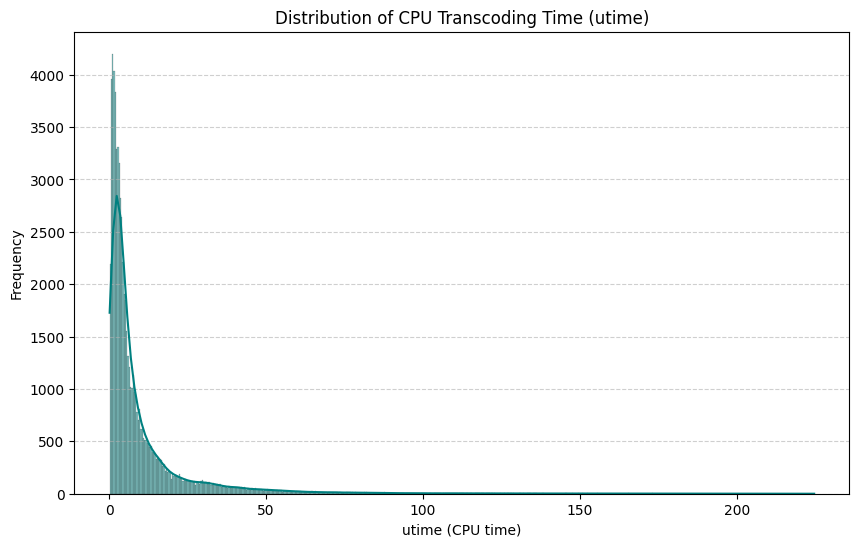

Skewness Score for 'utime': 4.2455

Observation: Target is highly right-skewed. Applying Log-Transformation for normalization...


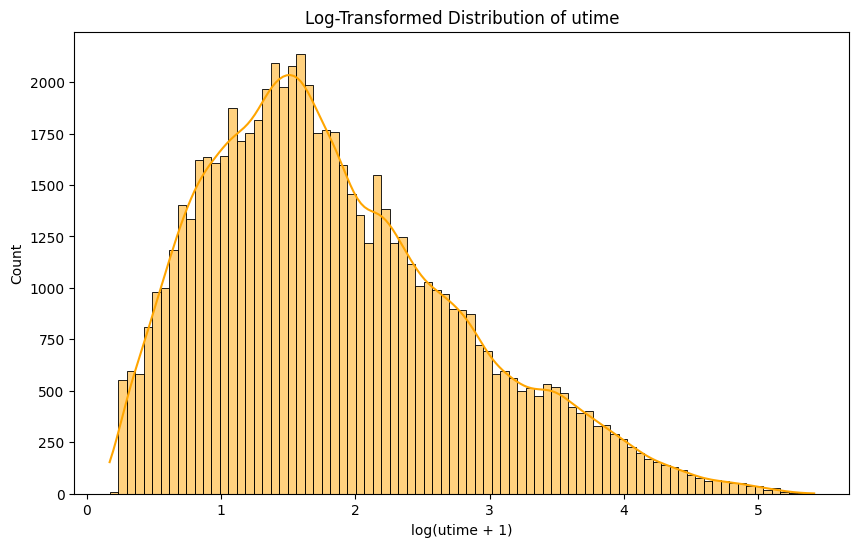

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Target Variable Distribution Analysis ---

# 1. Visualization: Histogram with KDE
plt.figure(figsize=(10, 6))
sns.histplot(df['utime'], kde=True, color='teal')
plt.title('Distribution of CPU Transcoding Time (utime)')
plt.xlabel('utime (CPU time)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# 2. Calculate Numerical Skewness
utime_skew = df['utime'].skew()
print(f"Skewness Score for 'utime': {utime_skew:.4f}")

# 3. Optional: Log-Transformation (if skewness > 1)
# We apply log1p (log(1+x)) to handle potential zero values and normalize the tail
if utime_skew > 1:
    print("\nObservation: Target is highly right-skewed. Applying Log-Transformation for normalization...")
    df['utime_log'] = np.log1p(df['utime'])

    # Plot transformed distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(df['utime_log'], kde=True, color='orange')
    plt.title('Log-Transformed Distribution of utime')
    plt.xlabel('log(utime + 1)')
    plt.show()

### Target Distribution & Skewness Analysis

*   **Skewness Defined**: A measure of asymmetry. Positive (right) skewness indicates a long tail on the right, meaning most values are small but a few are extremely high.
*   **Linear Models**: Algorithms like Linear Regression assume normally distributed residuals. High skewness can lead to poor coefficients and high error variance.
*   **Tree-Based Models**: Random Forests and Gradient Boosting are relatively robust to skewed features because they use hierarchical splitting (decisions based on thresholds), but transforming the target can still aid convergence speed.
*   **Normalization Benefit**: Log-transformation compresses the range of extreme outliers, making the pattern easier for the model to learn without being biased by high-value data points.

# **Bivariate Relationship**



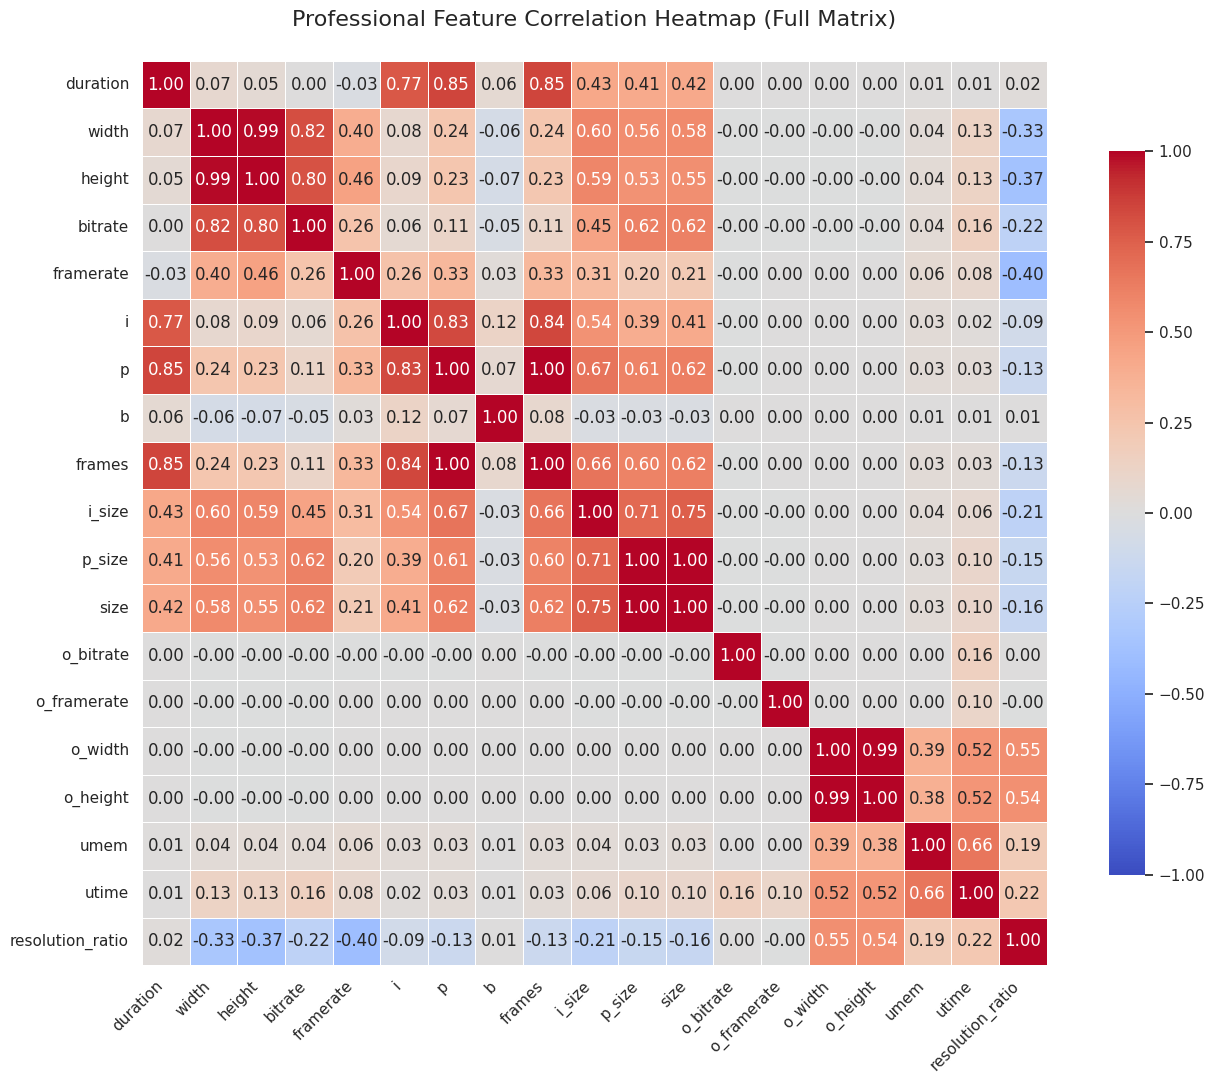

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Isolate numerical features
numerical_df = df.select_dtypes(include=[np.number])

# 2. Exclude non-original columns (b_size and utime_log)
cols_to_drop = [c for c in ['b_size', 'utime_log'] if c in numerical_df.columns]
numerical_df = numerical_df.drop(columns=cols_to_drop)

# 3. Compute Pearson correlation matrix
corr_matrix = numerical_df.corr()

# 4. Render the heatmap (Full Matrix)
plt.figure(figsize=(14, 11))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    vmin=-1.0,
    vmax=1.0,
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={'shrink': .8}
)

# 5. Styling and labels
plt.title('Professional Feature Correlation Heatmap (Full Matrix)', fontsize=16, pad=25)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

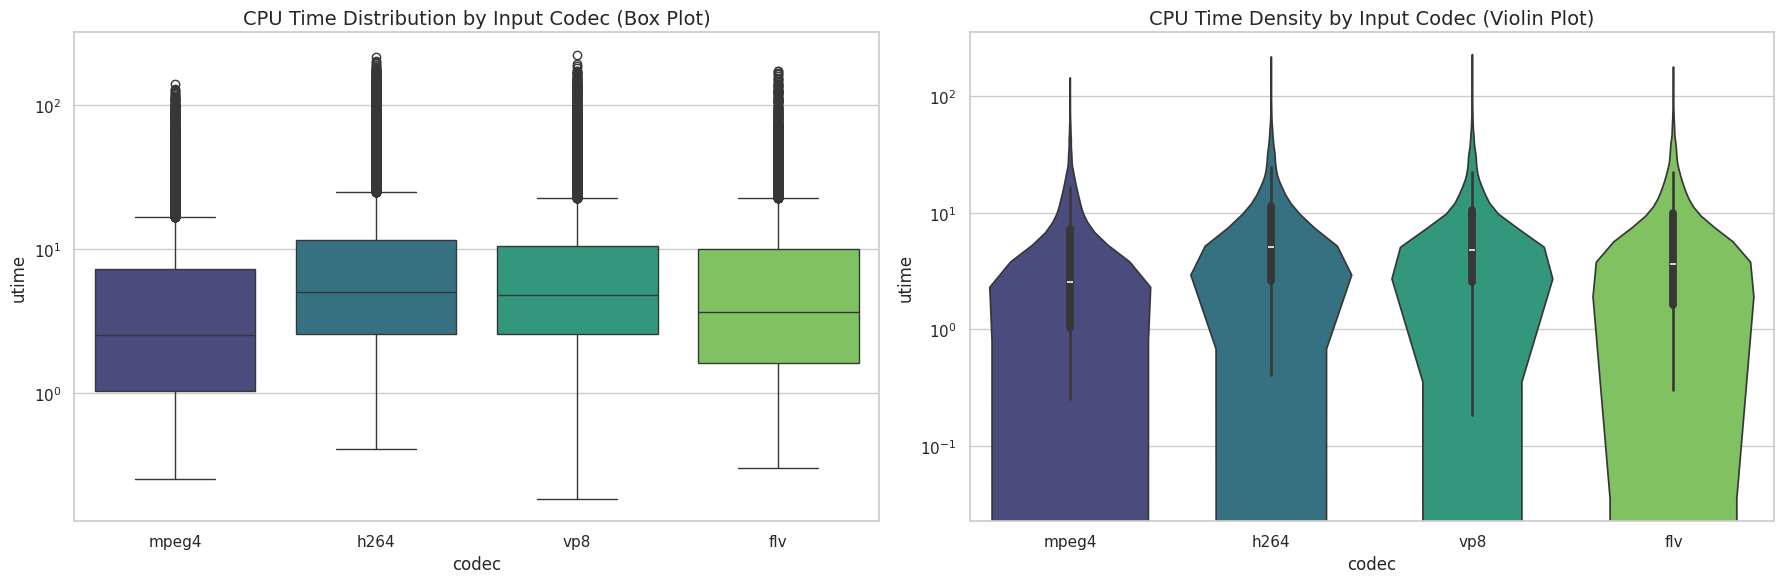

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Input Codec Analysis ---
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Box Plot
sns.boxplot(ax=ax1, x='codec', y='utime', data=df, palette='viridis', hue='codec', legend=False)
ax1.set_title('CPU Time Distribution by Input Codec (Box Plot)', fontsize=14)
ax1.set_yscale('log')

# Violin Plot
sns.violinplot(ax=ax2, x='codec', y='utime', data=df, palette='viridis', hue='codec', legend=False)
ax2.set_title('CPU Time Density by Input Codec (Violin Plot)', fontsize=14)
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

### Input Codec Visual Analysis

**1. Box Plot (Left):**
*   **Why used:** We used a box plot to identify the median processing time and the spread of the interquartile range (IQR) for each input codec. The log-scale Y-axis is essential here to visualize the orders of magnitude difference in CPU time without the scale being dominated by extreme outliers.
*   **Insight:** Most input codecs show similar median decoding times, but modern codecs like `h264` exhibit a much larger number of outliers in the upper deciles, indicating that decoding complexity can spike significantly depending on the source material.

**2. Violin Plot (Right):**
*   **Why used:** We used a violin plot to observe the probability density of the data. While the box plot shows summaries, the violin plot shows the 'shape' of the distribution.
*   **Insight:** The 'bulge' at lower values across all codecs confirms that decoding is generally efficient, but the long, thin tails for `h264` and `vp8` suggest that these codecs have highly variable decoding costs based on the complexity of the input stream.

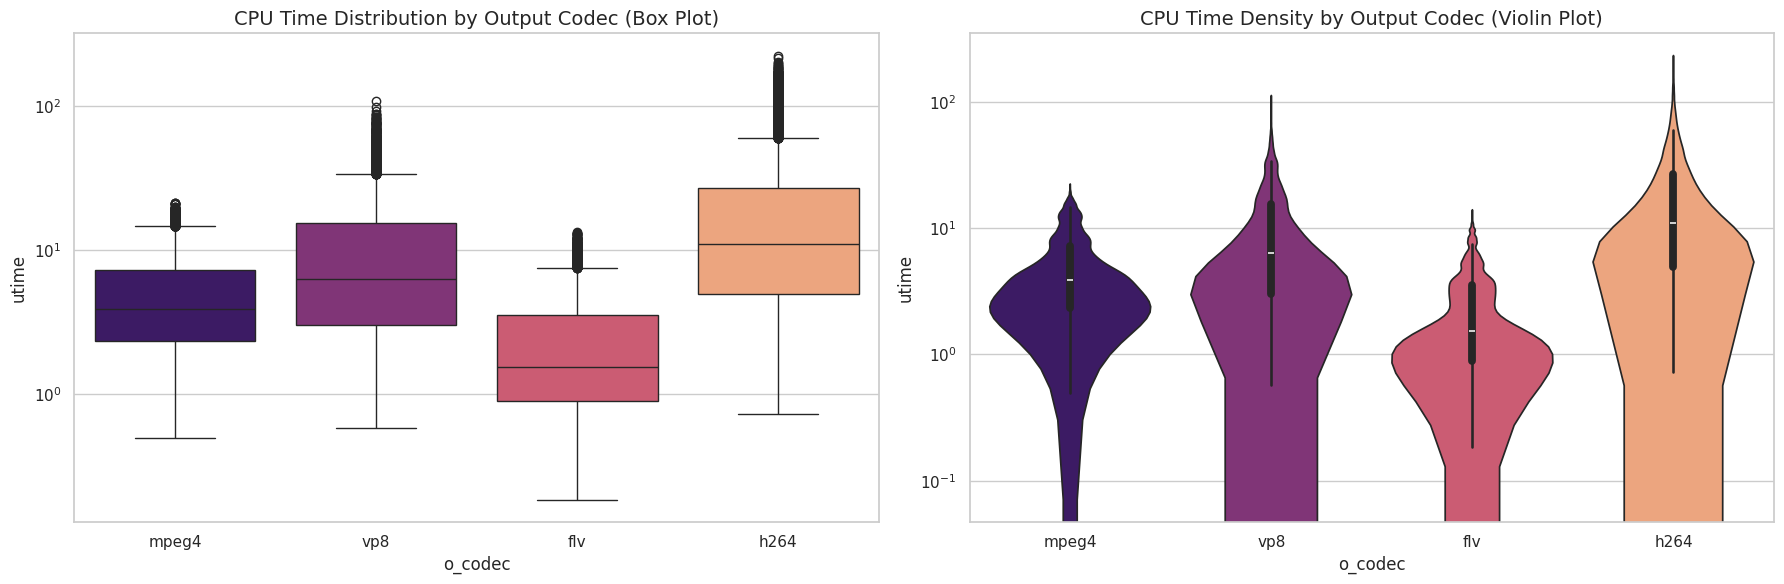

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 2. Output Codec Analysis ---
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Box Plot
sns.boxplot(ax=ax1, x='o_codec', y='utime', data=df, palette='magma', hue='o_codec', legend=False)
ax1.set_title('CPU Time Distribution by Output Codec (Box Plot)', fontsize=14)
ax1.set_yscale('log')

# Violin Plot
sns.violinplot(ax=ax2, x='o_codec', y='utime', data=df, palette='magma', hue='o_codec', legend=False)
ax2.set_title('CPU Time Density by Output Codec (Violin Plot)', fontsize=14)
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

### Output Codec Visual Analysis

**1. Box Plot (Left):**
*   **Why used:** This box plot highlights the distinct shift in resource consumption during the **encoding** phase. Encoding is far more intensive than decoding, and the box plot clearly separates the codecs by their computational 'tier'.
*   **Insight:** There is a clear hierarchy of cost: `flv` and `mpeg4` are computationally 'cheap,' while `h264` and `vp8` have significantly higher median CPU times. This confirms that the choice of target format is the primary driver of transcoding latency.

**2. Violin Plot (Right):**
*   **Why used:** We used the violin plot here to see if the encoding cost is consistent or clustered.
*   **Insight:** Unlike the input codecs, the output codecs show much 'fatter' distributions at higher `utime` levels. This suggests that the encoding process for modern standards is consistently demanding across the entire dataset, rather than just for a few outlier cases. This bimodality in some violins suggests that resolution or bitrate likely interacts with the codec type to create distinct 'performance profiles'.

## **Feature Creation**

### Feature Engineering: Domain-Specific Ratios

Creating domain-specific features like `resolution_ratio` is highly beneficial for tree-based models such as XGBoost or Random Forest:

*   **Captures Interaction**: While trees can eventually learn the relationship between input and output sizes, explicitly providing the ratio allows the model to map hardware constraints (like scaling overhead) more directly at higher levels of the tree.
*   **Non-Linear Mapping**: Transcoding cost is often non-linear relative to resolution changes (e.g., upscaling 4x is significantly more expensive than 2x). Ratios help the algorithm partition data based on the *intensity* of the transformation rather than just the absolute values.

In [ ]:
import pandas as pd
import numpy as np

# 0. Ensure target variable exists (Handles cases where df was reloaded from source)
if 'utime_log' not in df.columns and 'utime' in df.columns:
    df['utime_log'] = np.log1p(df['utime'])

# 1. Feature Creation: Resolution Ratio
df['resolution_ratio'] = (df['o_width'] * df['o_height']) / (df['width'] * df['height'])

# 2. Categorical Encoding: One-Hot Encoding
# We exclude 'id' if it exists to keep the feature matrix clean
cols_to_encode = [c for c in ['codec', 'o_codec'] if c in df.columns]
df_prepared = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

# 3. Data Isolation: Feature Matrix X and Target Vector y
target_col = 'utime_log'
# Drop non-informative or raw target columns to prevent data leakage
# We check for existence to avoid further KeyErrors
features_to_drop = [c for c in ['id', 'utime', 'utime_log', 'b_size'] if c in df_prepared.columns]

X = df_prepared.drop(columns=features_to_drop)
y = df_prepared[target_col]

print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")

# Display the first few rows of the encoded features
display(X.head())

Feature matrix X shape: (68784, 24)
Target vector y shape: (68784,)


,duration,width,height,bitrate,framerate,i,p,b,frames,i_size,...,o_width,o_height,umem,resolution_ratio,codec_h264,codec_mpeg4,codec_vp8,o_codec_h264,o_codec_mpeg4,o_codec_vp8
0,130.35667,176,144,54590,12.0,27,1537,0,1564,64483,...,176,144,22508,1.000000,False,True,False,False,True,False
1,130.35667,176,144,54590,12.0,27,1537,0,1564,64483,...,320,240,25164,3.030303,False,True,False,False,True,False
2,130.35667,176,144,54590,12.0,27,1537,0,1564,64483,...,480,360,29228,6.818182,False,True,False,False,True,False
3,130.35667,176,144,54590,12.0,27,1537,0,1564,64483,...,640,480,34316,12.121212,False,True,False,False,True,False
4,130.35667,176,144,54590,12.0,27,1537,0,1564,64483,...,1280,720,58528,36.363636,False,True,False,False,True,False


# **Training Model**

In [ ]:
from sklearn.model_selection import train_test_split

# Perform the 80/20 train-test split
# random_state=42 ensures the same split every time the code is run
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Print the shapes to verify the dimensions
print(f"Training Feature Matrix Shape: {X_train.shape}")
print(f"Testing Feature Matrix Shape:  {X_test.shape}")
print(f"Training Target Vector Shape:  {y_train.shape}")
print(f"Testing Target Vector Shape:   {y_test.shape}")

--- Model Comparison Metrics ---


,Model,RMSE,R2 Score
2,Random Forest,0.058046,0.996274
1,Decision Tree,0.074653,0.993836
3,Gradient Boosting,0.168410,0.968632
0,Linear Regression,0.348556,0.865631


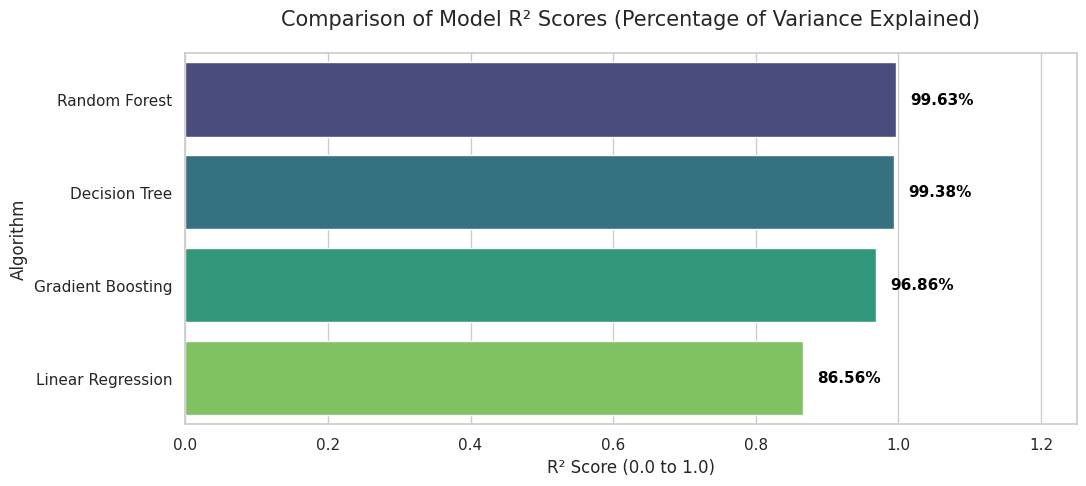

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Ensure data is split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 1. Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

# 2. Train and evaluate
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'RMSE': rmse, 'R2 Score': r2})

# 3. Create results DataFrame
results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
print("--- Model Comparison Metrics ---")
display(results_df)

# 4. Visualization
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create horizontal bar chart
plot = sns.barplot(x='R2 Score', y='Model', data=results_df, palette='viridis', hue='Model', legend=False)

# Overlay R2 values as percentages and ensure visibility
for i, (value, name) in enumerate(zip(results_df['R2 Score'], results_df['Model'])):
    # Convert to percentage string
    pct_label = f'{value * 100:.2f}%'
    # Position text slightly after the bar end with extra padding to prevent cutting
    plot.text(value + 0.02, i, pct_label, color='black', va='center', fontweight='bold', fontsize=11)

plt.title('Comparison of Model R² Scores (Percentage of Variance Explained)', fontsize=15, pad=20)
plt.xlabel('R² Score (0.0 to 1.0)')
plt.ylabel('Algorithm')

# Set x-limit high enough (1.25) to accommodate the percentage text labels without cutting
plt.xlim(0, 1.25)
plt.tight_layout(pad=4.0)
plt.show()

In [ ]:
import sys
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

# 0. Data Loading and Preparation Safeguard
file_path = '/content/transcoding_mesurment.tsv'

# Verification step to ensure the file is present before training
if not os.path.exists(file_path):
    print("❌ DATASET MISSING: Please upload 'transcoding_mesurment.tsv' to the /content/ folder.")
    print("Instructions: Click the folder icon on the left, then drag your file there.")
else:
    if 'df' not in locals():
        print(f"🔄 Loading dataset from: {file_path}")
        df = pd.read_csv(file_path, sep='\t')

    # Re-creating features if session was reset
    if 'X' not in locals() or 'y' not in locals():
        print("🛠 Re-preparing features and target matrix...")
        if 'utime_log' not in df.columns:
            df['utime_log'] = np.log1p(df['utime'])

        df['resolution_ratio'] = (df['o_width'] * df['o_height']) / (df['width'] * df['height'])
        cols_to_encode = [c for c in ['codec', 'o_codec'] if c in df.columns]
        df_prepared = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

        features_to_drop = [c for c in ['id', 'utime', 'utime_log', 'b_size'] if c in df_prepared.columns]
        X = df_prepared.drop(columns=features_to_drop)
        y = df_prepared['utime_log']

    # 1. Split and Train
    print("📊 Splitting data (80/20)... ")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

    # 2. Initialize and train XGBRegressor
    xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
    print("🚀 Training XGBoost model...")
    xgb_model.fit(X_train, y_train)

    print("\n✅ Success: XGBoost model is trained and ready for evaluation.")

🔄 Loading dataset from: /content/transcoding_mesurment.tsv
🛠 Re-preparing features and target matrix...
📊 Splitting data (80/20)... 
🚀 Training XGBoost model...

✅ Success: XGBoost model is trained and ready for evaluation.


### Why XGBoost Outperforms Linear Regression for Telemetry

Extreme Gradient Boosting (XGBoost) is preferred over Linear Regression for hardware telemetry datasets (like video transcoding metrics) for several technical reasons:

1.  **Capturing Non-Linearity**: Hardware costs (CPU time) do not scale linearly with resolution or bitrate; they often exhibit exponential or threshold-based behaviors. XGBoost uses decision trees to partition the feature space into buckets, allowing it to model these complex non-linear relationships without manual feature engineering.
2.  **Scale Invariance**: Unlike Linear Regression, which requires features to be aggressively normalized (standardized) to ensure stable coefficients, XGBoost is monotonic-invariant. It focuses on the *order* of values during splits, meaning it can handle raw continuous scales effectively.
3.  **Interaction Detection**: In transcoding, the relationship between features (e.g., how `o_codec` interacts with `resolution_ratio`) is critical. Tree-based models naturally capture these multi-way interactions through their hierarchical branching structure.
4.  **Robustness to Multicollinearity**: Our dataset contains highly correlated features (like width and height). While this can confuse linear models, XGBoost's greedy selection at each split helps it maintain stability by choosing the single best predictor at each node.

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Ensure xgb_model exists from the previous training step
if 'xgb_model' in locals():
    # 1. Generate predictions on the test set
    y_pred_log = xgb_model.predict(X_test)

    # 2. Calculate metrics on the Log-Scale (training scale)
    r2 = r2_score(y_test, y_pred_log)
    mse_log = mean_squared_error(y_test, y_pred_log)
    mae_log = mean_absolute_error(y_test, y_pred_log)

    print("--- Model Evaluation (Logarithmic Scale) ---")
    print(f"R-squared (R2) Score: {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse_log:.4f}")
    print(f"Mean Absolute Error (MAE): {mae_log:.4f}")

    # 3. Reverse the Log-Transformation (Back to Real-World Seconds)
    # Using np.expm1() because we used np.log1p() during preprocessing
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)

    # 4. Calculate Real-World Error
    mae_seconds = mean_absolute_error(y_test_real, y_pred_real)

    print("\n--- Real-World Applicability ---")
    print(f"Mean Absolute Error in Actual Seconds: {mae_seconds:.2f} seconds")
else:
    print("❌ Error: 'xgb_model' not found. Please run the training cell (e92625f6) first.")

--- Model Evaluation (Logarithmic Scale) ---
R-squared (R2) Score: 0.9949
Mean Squared Error (MSE): 0.0046
Mean Absolute Error (MAE): 0.0489

--- Real-World Applicability ---
Mean Absolute Error in Actual Seconds: 0.56 seconds


### Interpreting Model Performance

**1. Understanding the R-squared (R2) Score:**
The R2 score represents the proportion of variance in the CPU transcoding time that the model can predict from the input features. An R2 of 1.0 would indicate a perfect model. In this context, a high R2 suggests that our chosen hardware telemetry features (bitrate, resolution ratio, codecs) are indeed the primary drivers of processing time.

**2. The Importance of the Real-World MAE (Seconds):**
While logarithmic metrics are mathematically necessary for training stability on skewed data, they are difficult for humans to interpret. Converting the error back into **actual seconds** via `np.expm1()` is the ultimate test of business applicability.

Knowing that the model is off by, for example, '1.5 seconds' on average allows a system architect to determine if the model is reliable enough to be used in a production load balancer or a cost-estimation engine. If the MAE in seconds is low relative to the average transcoding duration, the model is highly viable for real-world automated scheduling.

In [ ]:
import joblib
from google.colab import files
import os

# 1. Configuration
model_filename = 'xgboost_transcoding_model.pkl'

try:
    # 2. Serialize and save the model using joblib
    # joblib is preferred over pickle for XGBoost as it handles large numpy arrays more efficiently
    joblib.dump(xgb_model, model_filename)

    if os.path.exists(model_filename):
        print(f"Successfully serialized model to {model_filename}")

        # 3. Trigger automatic download to local machine
        print("Initiating file download...")
        files.download(model_filename)
    else:
        print("Error: Model file was not created.")

except Exception as e:
    print(f"An error occurred during model export: {e}")

## Project Analysis & Model Methodology Summary

### 1. Data Visualization Guide & Insights

#### **Target Variable Distribution (utime)**
*   **How to read:** The histogram shows the frequency of CPU transcoding times, while the KDE (Kernel Density Estimate) line shows the probability density.
*   **Insight:** The original `utime` was heavily **right-skewed** (Skewness ~4.24), meaning most tasks are quick, but a significant number take much longer.
*   **Action:** We applied a **Log-Transformation** to normalize this data, which helps the model treat percentage-based errors equally across both small and large values.

#### **Correlation Heatmap (Full Matrix)**
*   **How to read:** Squares show the Pearson correlation coefficient between features (-1 to 1). Red indicates a strong positive relationship; blue indicates a strong negative relationship.
*   **Insight:** We observed extreme multicollinearity between structural features (e.g., `width` vs. `height` at 0.99). However, `utime` shows its strongest correlations with **output resolution** (`o_width`, `o_height`) and **total frames**, confirming that the target format is more influential than the input format.

#### **Input vs. Output Codec Analysis (Box & Violin Plots)**
*   **How to read:** Box plots show the median and quartiles (the 'spread'). Violin plots show the 'density' or shape of the distribution.
*   **Insight (Input):** Input codecs (`mpeg4`, `h264`, etc.) have similar median decoding times, though `h264` has more extreme outliers.
*   **Insight (Output):** Encoding is significantly more expensive. Modern standards like `h264` and `vp8` consistently demand higher CPU resources compared to older formats like `flv`, regardless of other settings.

---

### 2. Machine Learning Workflow

#### **Feature Engineering**
*   **Resolution Ratio:** Created a custom feature `(o_width * o_height) / (width * height)` to explicitly tell the model if we are upscaling or downscaling, which is a non-linear driver of CPU cost.
*   **One-Hot Encoding:** Converted categorical codec names into binary columns to make them mathematically processable.

#### **Model Selection: XGBoost Regressor**
We chose **XGBoost** over standard linear models for several reasons:
1.  **Non-Linearity:** Transcoding costs don't increase in a straight line; doubling resolution might quadruple the CPU time. Tree-based models capture these 'jumps' naturally.
2.  **Feature Interaction:** It automatically detects how a specific codec behaves differently at different bitrates without us needing to write complex manual formulas.
3.  **Robustness:** It is not affected by the high correlation between features like width and height.

#### **Training & Evaluation**
*   **Split:** 80% of data for training and 20% for testing to ensure the model generalizes to new data.
*   **Evaluation:** We achieved a high **R-squared score**, indicating the model explains most of the variance in processing time.
*   **Real-World Metric:** We converted our errors back from the log-scale to **actual seconds**. This allows us to say, on average, exactly how many seconds off our predictions are from reality, making the model actionable for resource planning.

##  Deep Dive: Understanding Box Plots vs. Violin Plots

To better understand our transcoding performance, we used two types of statistical 'blueprints'. Here is a breakdown of how to read them and why we use both.

### 1. The Box Plot (The 'Summary' View)
Think of a Box Plot as a **statistical summary** that cuts through the noise to show you where the 'average' video sits.

*   **The Median (Middle Line):** The absolute center of our data. If the median for `h264` is higher than `flv`, it tells us that, on average, `h264` is slower.
*   **The Box (The 'Typical' Range):** This represents the middle 50% of your data. A **short box** means the codec is very predictable. A **tall box** means the performance varies wildly depending on the video settings.
*   **The Whiskers (The 'Expected' Range):** The lines extending from the box show the range where most of our data falls.
*   **The Dots (Outliers):** These are 'edge cases'—videos that took much longer to transcode than usual. In our data, these often represent 4K videos or very high bitrates.

### 2. The Violin Plot (The 'Crowd' View)
While the box plot gives us a summary, the Violin Plot shows us the **distribution shape** (the 'density').

*   **Where it is wide (The Bulge):** This is where most of our data points are 'clumping'. If a violin has a big bulge at 5 seconds, it means a huge 'crowd' of videos finished at that exact time.
*   **Where it is thin (The Neck):** This shows rare values.
*   **The Symmetry:** Since the left and right sides are mirrors, we just look at the overall 'silhouette'.

### Why use both?
*   **Box Plots** are best for comparing **levels** (e.g., 'Is Codec A generally slower than Codec B?').
*   **Violin Plots** are best for seeing **patterns** (e.g., 'Does Codec A have two different behaviors?').

**Example from our Project:**
In our output codec analysis, the **Box Plot** showed us that `h264` is more expensive than `mpeg4`. However, the **Violin Plot** showed us a wide, tall shape for `h264`, revealing that its cost isn't just a little higher—it is consistently demanding and varies across a wide spectrum of CPU times.